In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score


In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
DATA_PATH = "../results/outputs/scaled.csv"
TARGET_COL = "Status"

In [3]:
data = pd.read_csv(DATA_PATH)
X = data.drop(columns=[TARGET_COL])
y = data[TARGET_COL]

print("✅ Dataset loaded successfully!")
print("Shape:", X.shape)
print("Target distribution:")
print(y.value_counts(), "\n")

# Detect if binary or multiclass
classes = sorted(y.unique())
num_classes = len(classes)
is_binary = num_classes == 2
print(f"Detected {num_classes} class(es): {classes}")

✅ Dataset loaded successfully!
Shape: (15000, 20)
Target distribution:
Status
0    5000
1    5000
2    5000
Name: count, dtype: int64 

Detected 3 class(es): [np.int64(0), np.int64(1), np.int64(2)]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print("Train/Test shapes:", X_train.shape, y_train.shape, "|", X_test.shape, y_test.shape)

Train/Test shapes: (12000, 20) (12000,) | (3000, 20) (3000,)


In [5]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [6]:
pipe_lr = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"))
])
param_grid_lr = {"clf__penalty": ["l1", "l2"], "clf__C": [0.01, 0.1, 1.0, 10.0]}

pipe_svm = Pipeline([
    ("pre", preprocessor),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE))
])
param_grid_svm = {"clf__C": [0.1, 1, 10], "clf__gamma": ["scale", 0.01, 0.1, 1]}

pipe_dt = Pipeline([
    ("pre", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
])
param_grid_dt = {
    "clf__max_depth": [None, 3, 5, 10, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4]
}

models_and_grids = [
    ("LogisticRegression", pipe_lr, param_grid_lr),
    ("SVM", pipe_svm, param_grid_svm),
    ("DecisionTree", pipe_dt, param_grid_dt)
]

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "recall": "recall_weighted",
    "f1": "f1_weighted"
}

In [7]:
best_estimators = {}
cv_results = []

for name, pipe, grid in models_and_grids:
    print(f"\n🔍 Training {name} with GridSearchCV...")
    gs = GridSearchCV(
        pipe, grid, scoring=scoring, refit="f1", cv=cv,
        n_jobs=-1, verbose=1, return_train_score=False
    )
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_

    idx = gs.best_index_
    res = {
        "Model": name,
        "Best Params": gs.cv_results_["params"][idx],
        "CV Accuracy": gs.cv_results_["mean_test_accuracy"][idx],
        "CV F1": gs.cv_results_["mean_test_f1"][idx],
    }
    print("✅ Best result:", res)
    cv_results.append(res)

cv_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:")
print(cv_df)


🔍 Training LogisticRegression with GridSearchCV...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ Best result: {'Model': 'LogisticRegression', 'Best Params': {'clf__C': 0.1, 'clf__penalty': 'l2'}, 'CV Accuracy': np.float64(0.6636666666666666), 'CV F1': np.float64(0.6617258930130625)}

🔍 Training SVM with GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
✅ Best result: {'Model': 'SVM', 'Best Params': {'clf__C': 10, 'clf__gamma': 0.1}, 'CV Accuracy': np.float64(0.96), 'CV F1': np.float64(0.9599627880162673)}

🔍 Training DecisionTree with GridSearchCV...
Fitting 5 folds for each of 45 candidates, totalling 225 fits
✅ Best result: {'Model': 'DecisionTree', 'Best Params': {'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}, 'CV Accuracy': np.float64(0.96675), 'CV F1': np.float64(0.9667598688250238)}

📊 Cross-Validation Results:
                Model                                        Best Params  \
0  LogisticRegress


=== LogisticRegression ===
Accuracy=0.6583 | Precision=0.6616 | Recall=0.6583 | F1=0.6551 | AUC=0.8206
              precision    recall  f1-score   support

           0      0.615     0.737     0.671      1000
           1      0.701     0.717     0.709      1000
           2      0.669     0.521     0.586      1000

    accuracy                          0.658      3000
   macro avg      0.662     0.658     0.655      3000
weighted avg      0.662     0.658     0.655      3000



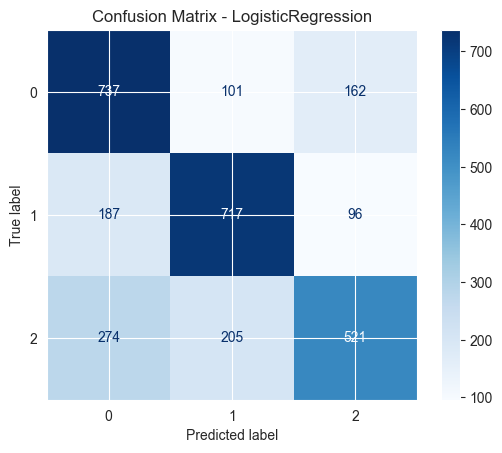


=== SVM ===
Accuracy=0.9637 | Precision=0.9637 | Recall=0.9637 | F1=0.9637 | AUC=0.9926
              precision    recall  f1-score   support

           0      0.946     0.949     0.948      1000
           1      0.985     0.986     0.986      1000
           2      0.960     0.956     0.958      1000

    accuracy                          0.964      3000
   macro avg      0.964     0.964     0.964      3000
weighted avg      0.964     0.964     0.964      3000



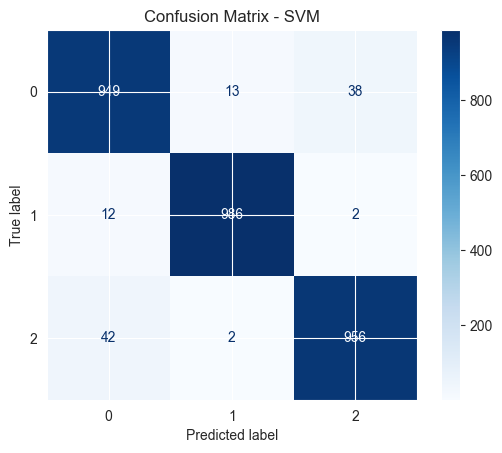


=== DecisionTree ===
Accuracy=0.9713 | Precision=0.9713 | Recall=0.9713 | F1=0.9713 | AUC=0.9785
              precision    recall  f1-score   support

           0      0.969     0.965     0.967      1000
           1      0.976     0.985     0.981      1000
           2      0.969     0.964     0.966      1000

    accuracy                          0.971      3000
   macro avg      0.971     0.971     0.971      3000
weighted avg      0.971     0.971     0.971      3000



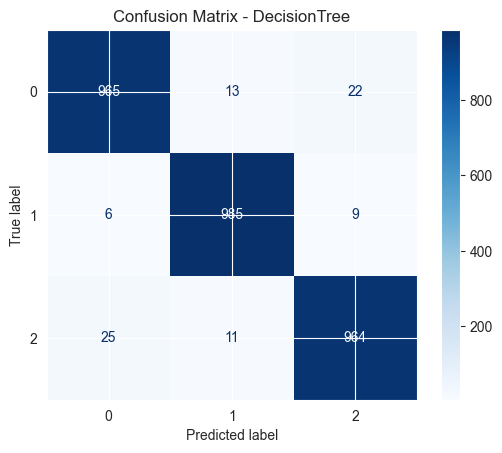


📈 Test Results Summary:
                Model  Accuracy  Precision    Recall        F1       AUC
0  LogisticRegression  0.658333   0.661626  0.658333  0.655060  0.820581
1                 SVM  0.963667   0.963672  0.963667  0.963667  0.992614
2        DecisionTree  0.971333   0.971311  0.971333  0.971312  0.978494


In [8]:
def evaluate_model(name, model):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    # AUC (only meaningful for binary or multilabel)
    if is_binary:
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = model.predict_proba(X_test)
        y_bin = label_binarize(y_test, classes=classes)
        auc = roc_auc_score(y_bin, y_prob, average="weighted", multi_class="ovr")

    cm = confusion_matrix(y_test, y_pred)
    print(f"\n=== {name} ===")
    print(f"Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f} | AUC={auc:.4f}")
    print(classification_report(y_test, y_pred, digits=3))
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    return [name, acc, prec, rec, f1, auc]

test_results = [evaluate_model(name, model) for name, model in best_estimators.items()]
test_df = pd.DataFrame(test_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"])
print("\n📈 Test Results Summary:")
print(test_df)

In [9]:
print("\n🔬 PCA & Logistic Regression comparison...")
pipe_lr_pca = Pipeline([
    ("pre", preprocessor),
    ("pca", PCA(n_components=10)),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"))
])
param_grid_lr_pca = {
    "pca__n_components": [5, 10, 15],
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.1, 1.0, 10.0]
}
gs_lr_pca = GridSearchCV(pipe_lr_pca, param_grid_lr_pca, scoring="f1_weighted", cv=cv, n_jobs=-1, verbose=1)
gs_lr_pca.fit(X_train, y_train)
lr_pca_best = gs_lr_pca.best_estimator_

def eval_short(name, model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    if is_binary:
        auc = roc_auc_score(y_test, y_prob[:, 1])
    else:
        y_bin = label_binarize(y_test, classes=classes)
        auc = roc_auc_score(y_bin, y_prob, average="weighted", multi_class="ovr")
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred, average="weighted"),
        "AUC": auc
    }

lr_compare = pd.DataFrame([
    eval_short("LR_No_PCA", best_estimators["LogisticRegression"]),
    eval_short("LR_With_PCA", lr_pca_best)
])
print("\n📘 Logistic Regression: PCA Comparison")
print(lr_compare)


🔬 PCA & Logistic Regression comparison...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

📘 Logistic Regression: PCA Comparison
         Model  Accuracy        F1       AUC
0    LR_No_PCA  0.658333  0.655060  0.820581
1  LR_With_PCA  0.623333  0.617853  0.786412



🌀 Running K-Means clustering on PCA(2)...
Silhouette Score: 0.4021 | Adjusted Rand Index: 0.0332


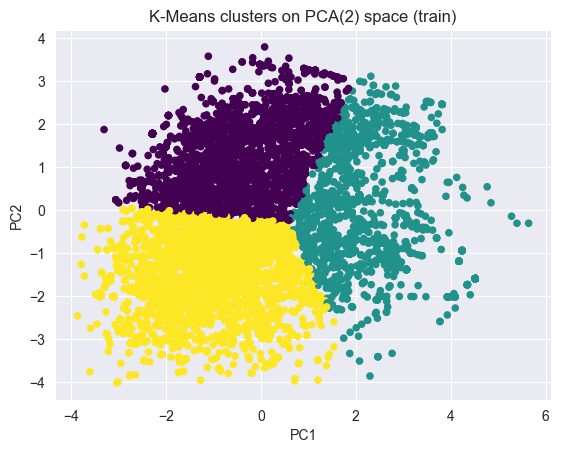

In [10]:
print("\n🌀 Running K-Means clustering on PCA(2)...")
pipe_pre = Pipeline([("pre", preprocessor)])
X_train_pre = pipe_pre.fit_transform(X_train)
pca2 = PCA(n_components=2).fit(X_train_pre)
X_train_2d = pca2.transform(X_train_pre)

k = num_classes if num_classes > 1 else 2
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
kmeans.fit(X_train_2d)
labels = kmeans.labels_
sil = silhouette_score(X_train_2d, labels)
ari = adjusted_rand_score(y_train, labels)
print(f"Silhouette Score: {sil:.4f} | Adjusted Rand Index: {ari:.4f}")

plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=labels, s=20, cmap="viridis")
plt.title("K-Means clusters on PCA(2) space (train)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [11]:
cv_df.to_csv("cv_results_summary.csv", index=False)
test_df.to_csv("test_results_summary.csv", index=False)
lr_compare.to_csv("lr_pca_comparison.csv", index=False)

print("\n💾 Results saved:")
print(" - cv_results_summary.csv")
print(" - test_results_summary.csv")
print(" - lr_pca_comparison.csv")
print("\n✅ All done, works for binary & multiclass!")


💾 Results saved:
 - cv_results_summary.csv
 - test_results_summary.csv
 - lr_pca_comparison.csv

✅ All done, works for binary & multiclass!
